SABINA COMMENT: One overarching feedback... where are my insights?????

Every chart going forward should have your thoughts underneath. What you see, why it's important for the business you're working with, etc.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("all_streaming_titles.csv")

# Convert date if needed
if "release_date" in df.columns:
    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

print(df.shape)
df.head()

(96200, 40)


,popularity_norm,engagement_score,release_date,popularity,id,adult,spoken_languages,hidden_gem,vote_average,network,...,original_language,production_companies,tentpole_content,official_site,production_countries,freshness_score,status,origin_country,genre_names,runtime_final
0,0.916136,7.789985,2018-10-16,385.1942,79744,0.0,English,0,8.529,NaN,...,English,"ABC Studios, Entertainment One, Lionsgate Tele...",1,NaN,"US, CA",0.922481,Returning Series,US,"Crime, Drama, Comedy",NaN
1,1.000000,2.340317,2026-02-12,420.4551,1265609,0.0,English,0,7.238,NaN,...,English,"Lionsgate, Hidden Pictures, Huge Film, Range M...",1,NaN,"AU, US",0.984496,Released,AU,"Action, Science Fiction, Thriller",110.0
2,0.796415,27.603475,2005-03-27,334.8569,1416,0.0,English,0,8.209,NaN,...,English,"The Mark Gordon Company, shondaland, ABC Studi...",1,NaN,"US, CA",0.821705,Returning Series,US,Drama,NaN
3,0.830130,21.134389,2005-09-13,349.0323,1622,0.0,English,0,8.300,NaN,...,English,"Kripke Enterprises, Supernatural Pictures, Won...",1,NaN,US,0.821705,Ended,US,"Drama, Mystery, Sci-Fi & Fantasy",NaN
4,0.445930,67.621359,2011-04-17,187.4934,1399,0.0,English,0,8.458,NaN,...,English,"Revolution Sun Studios, Television 360, Genera...",1,NaN,"GB, US",0.868217,Ended,US,"Sci-Fi & Fantasy, Drama, Action & Adventure",NaN


Total titles by content type

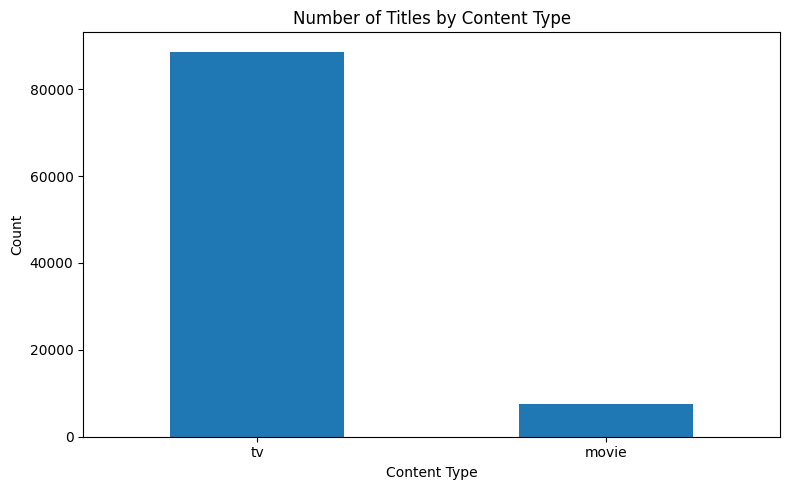

In [84]:
content_counts = df["content_type"].value_counts()

plt.figure(figsize=(8, 5))
content_counts.plot(kind="bar")
plt.title("Number of Titles by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Popularity distribution

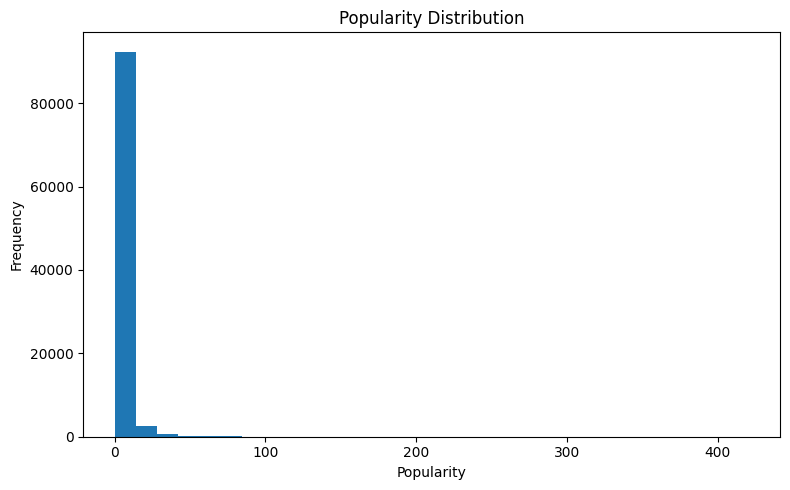

In [85]:
plt.figure(figsize=(8, 5))
plt.hist(df["popularity"].dropna(), bins=30)
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Vote count distribution

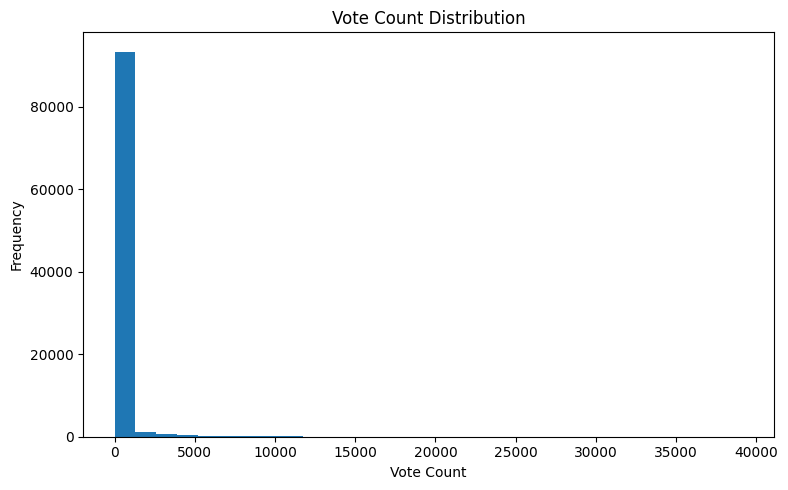

In [86]:
plt.figure(figsize=(8, 5))
plt.hist(df["vote_count"].dropna(), bins=30)
plt.title("Vote Count Distribution")
plt.xlabel("Vote Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Vote average distribution

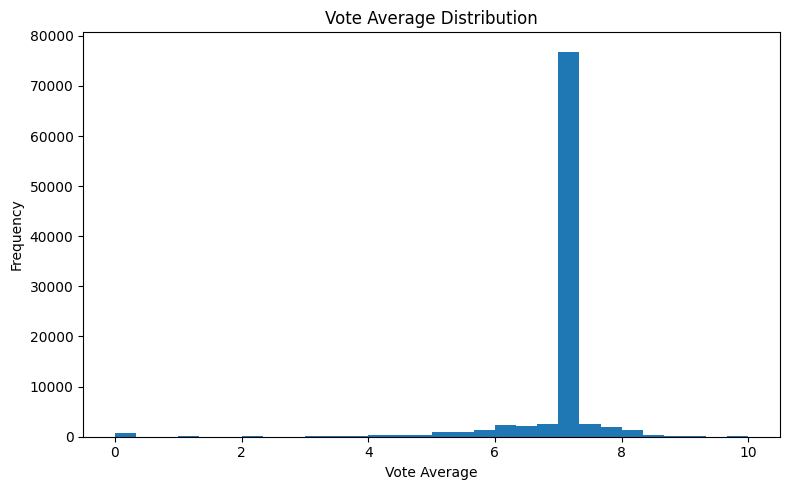

In [87]:
plt.figure(figsize=(8, 5))
plt.hist(df["vote_average"].dropna(), bins=30)
plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Release count by year

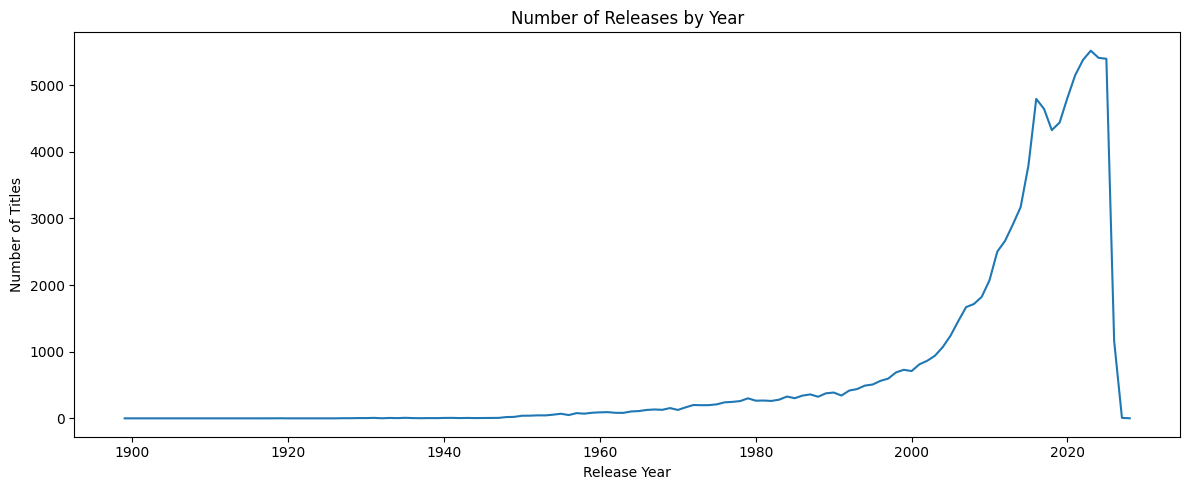

In [88]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Number of Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

Top 10 genres by content volume

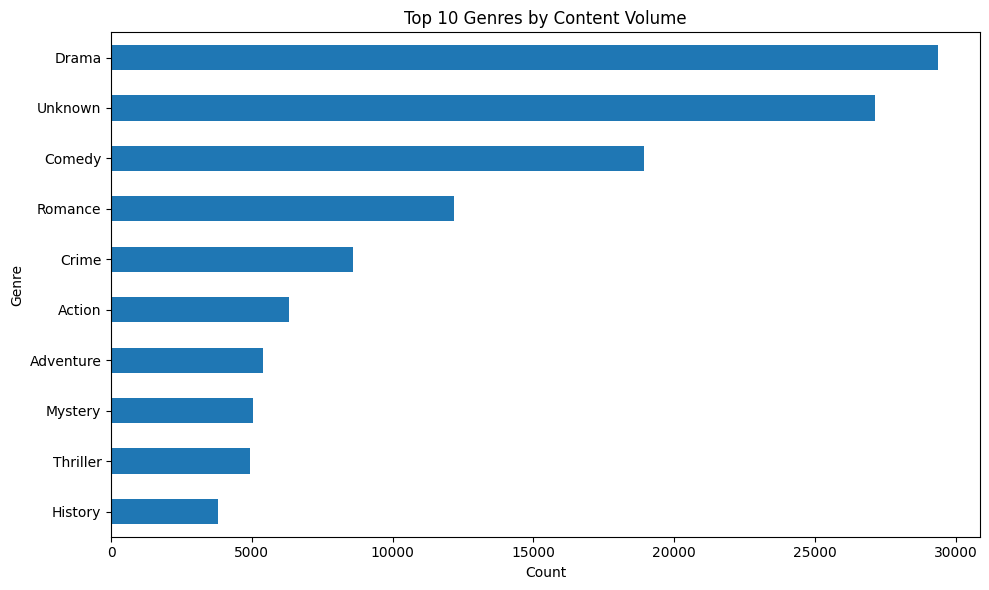

In [89]:
genre_exploded = df.copy()
genre_exploded["genre_names"] = genre_exploded["genre_names"].fillna("Unknown")
genre_exploded["genre_names"] = genre_exploded["genre_names"].str.split(", ")
genre_exploded = genre_exploded.explode("genre_names")

top_genres = genre_exploded["genre_names"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_genres.sort_values().plot(kind="barh")
plt.title("Top 10 Genres by Content Volume")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Top 10 languages by content volume

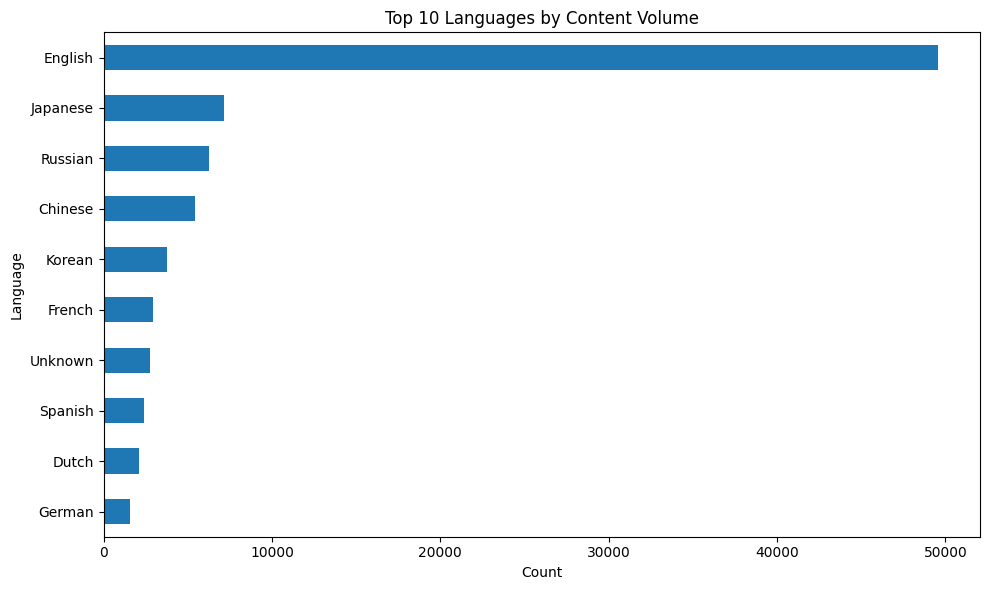

In [90]:
top_languages = df["original_language"].fillna("unknown").value_counts().head(10)

plt.figure(figsize=(10, 6))
top_languages.sort_values().plot(kind="barh")
plt.title("Top 10 Languages by Content Volume")
plt.xlabel("Count")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

Top genres by average visibility

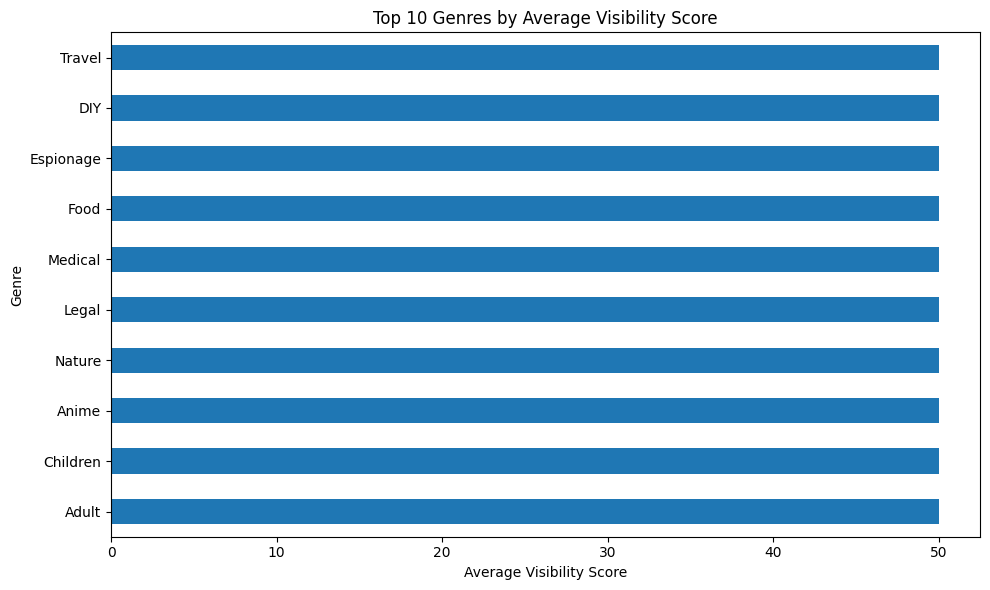

In [91]:
genre_exploded = df.copy()
genre_exploded["genre_names"] = genre_exploded["genre_names"].fillna("Unknown")
genre_exploded["genre_names"] = genre_exploded["genre_names"].str.split(", ")
genre_exploded = genre_exploded.explode("genre_names")

genre_visibility = (
    genre_exploded.groupby("genre_names")["visibility_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
genre_visibility.sort_values().plot(kind="barh")
plt.title("Top 10 Genres by Average Visibility Score")
plt.xlabel("Average Visibility Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Top genres by average engagement

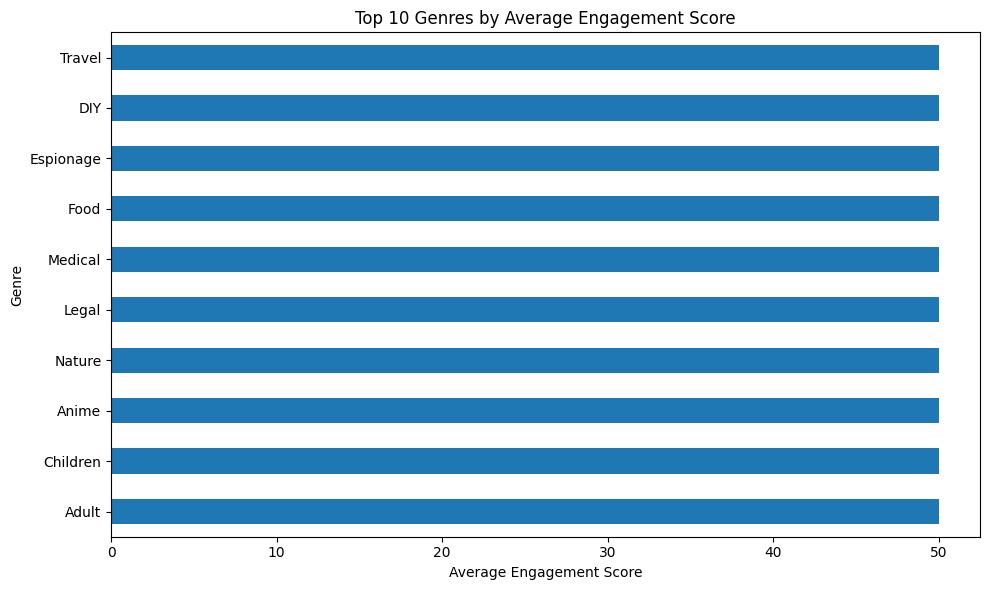

In [92]:
genre_exploded = df.copy()
genre_exploded["genre_names"] = genre_exploded["genre_names"].fillna("Unknown")
genre_exploded["genre_names"] = genre_exploded["genre_names"].str.split(", ")
genre_exploded = genre_exploded.explode("genre_names")

genre_engagement = (
    genre_exploded.groupby("genre_names")["engagement_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
genre_engagement.sort_values().plot(kind="barh")
plt.title("Top 10 Genres by Average Engagement Score")
plt.xlabel("Average Engagement Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Top genres by average business value

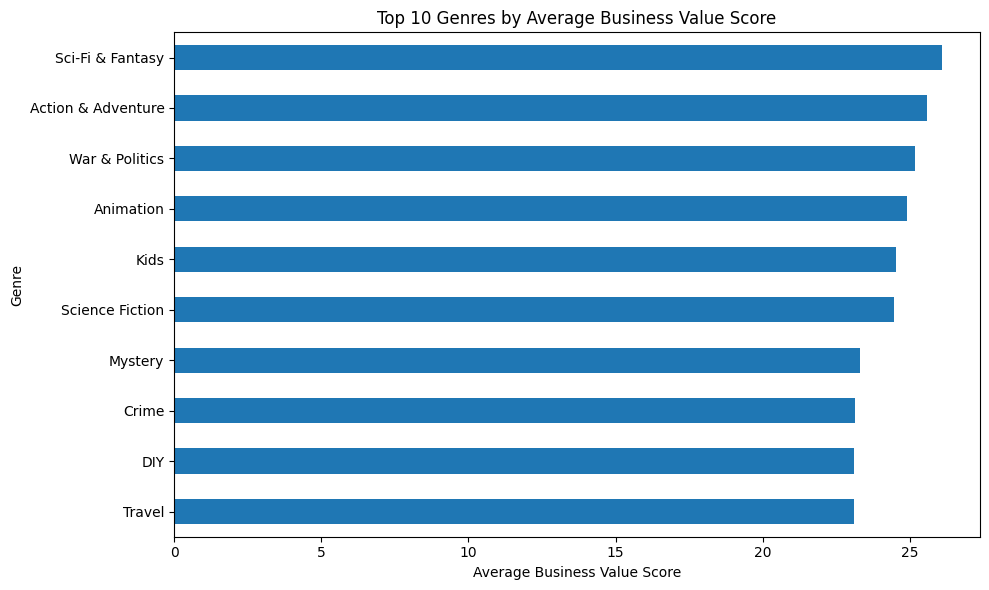

In [93]:
genre_exploded = df.copy()
genre_exploded["genre_names"] = genre_exploded["genre_names"].fillna("Unknown")
genre_exploded["genre_names"] = genre_exploded["genre_names"].str.split(", ")
genre_exploded = genre_exploded.explode("genre_names")

genre_business = (
    genre_exploded.groupby("genre_names")["business_value_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
genre_business.sort_values().plot(kind="barh")
plt.title("Top 10 Genres by Average Business Value Score")
plt.xlabel("Average Business Value Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Top languages by average visibility

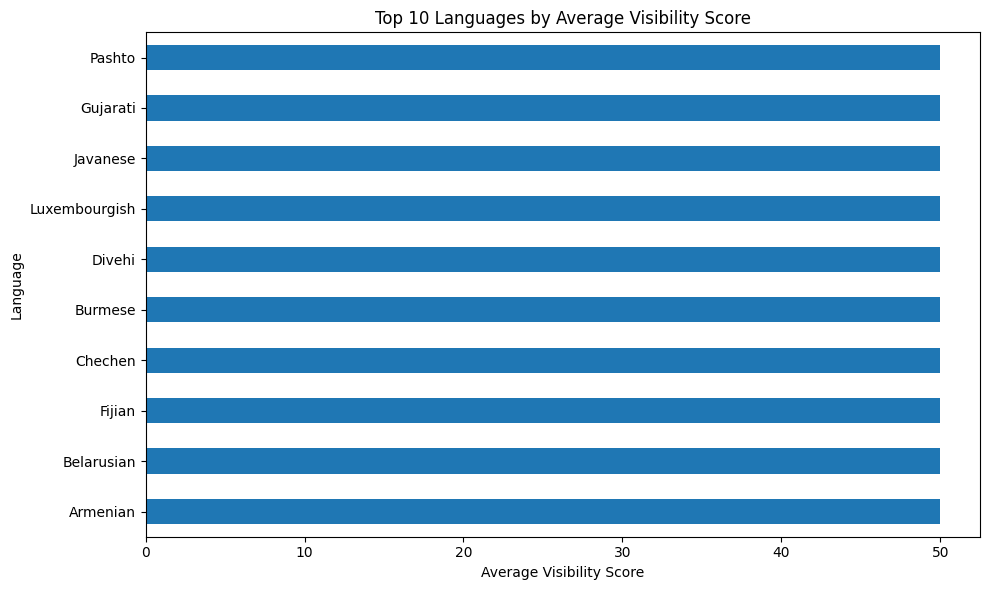

In [94]:
language_visibility = (
    df.groupby("original_language")["visibility_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
language_visibility.sort_values().plot(kind="barh")
plt.title("Top 10 Languages by Average Visibility Score")
plt.xlabel("Average Visibility Score")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

Top languages by average business value

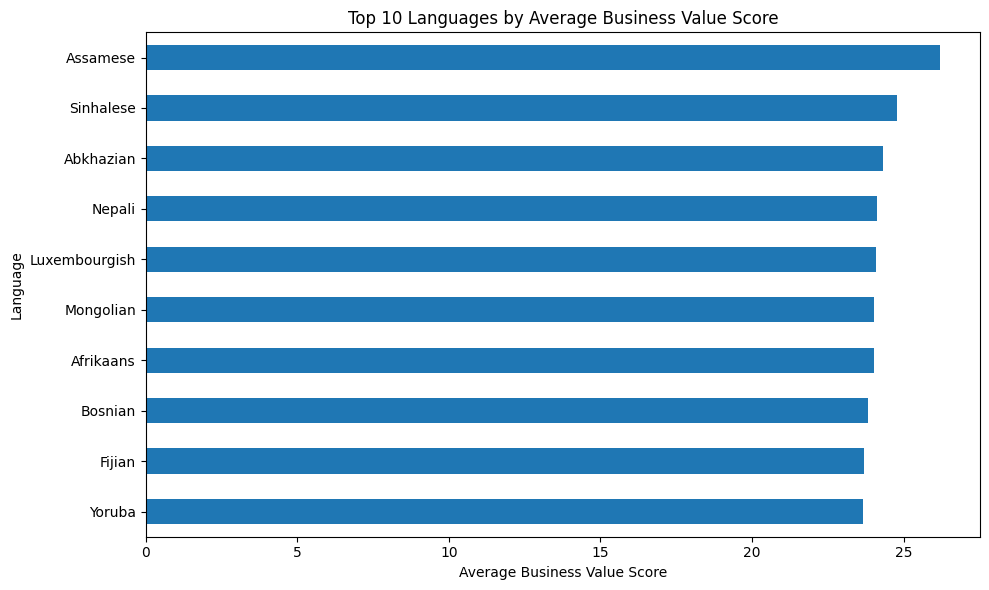

In [95]:
language_business = (
    df.groupby("original_language")["business_value_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
language_business.sort_values().plot(kind="barh")
plt.title("Top 10 Languages by Average Business Value Score")
plt.xlabel("Average Business Value Score")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

Movie vs TV popularity comparison

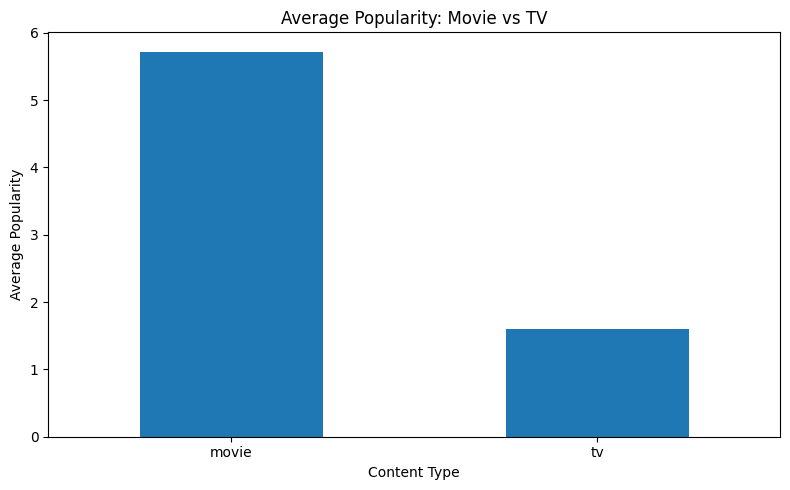

In [96]:
movie_tv_popularity = df.groupby("content_type")["popularity"].mean()

plt.figure(figsize=(8, 5))
movie_tv_popularity.plot(kind="bar")
plt.title("Average Popularity: Movie vs TV")
plt.xlabel("Content Type")
plt.ylabel("Average Popularity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Movie vs TV engagement comparison

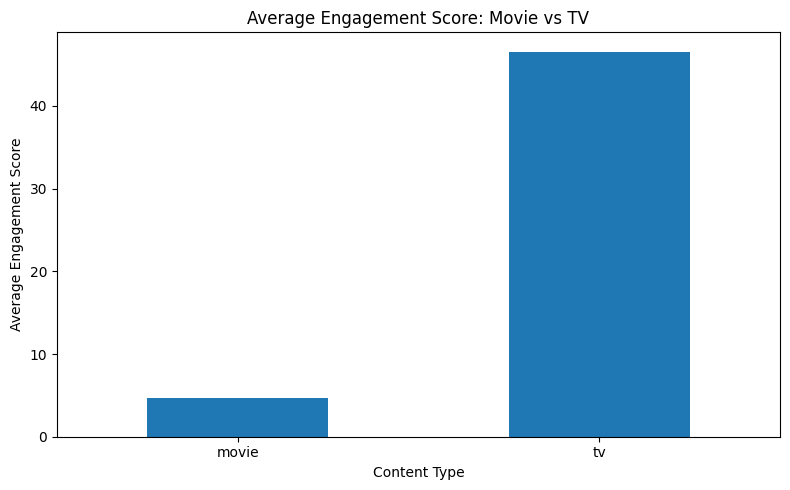

In [121]:
movie_tv_engagement = df.groupby("content_type")["engagement_score"].mean()

plt.figure(figsize=(8, 5))
movie_tv_engagement.plot(kind="bar")
plt.title("Average Engagement Score: Movie vs TV")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Movie vs TV business value comparison

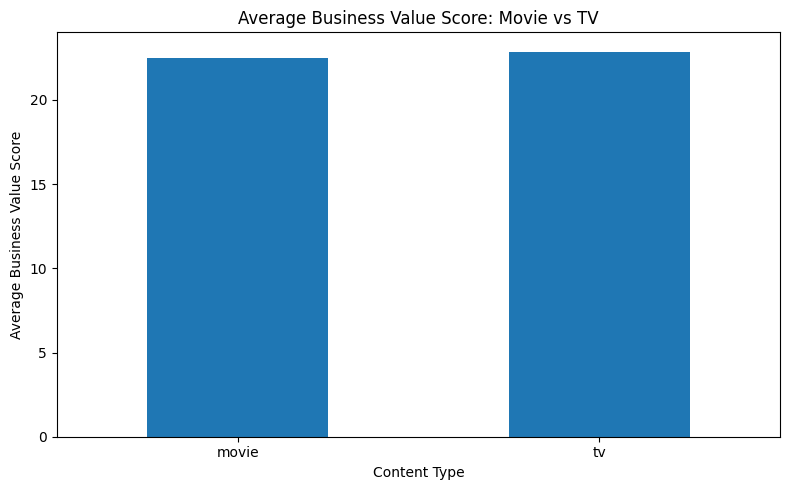

In [98]:
movie_tv_business = df.groupby("content_type")["business_value_score"].mean()

plt.figure(figsize=(8, 5))
movie_tv_business.plot(kind="bar")
plt.title("Average Business Value Score: Movie vs TV")
plt.xlabel("Content Type")
plt.ylabel("Average Business Value Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visibility vs engagement scatter plot

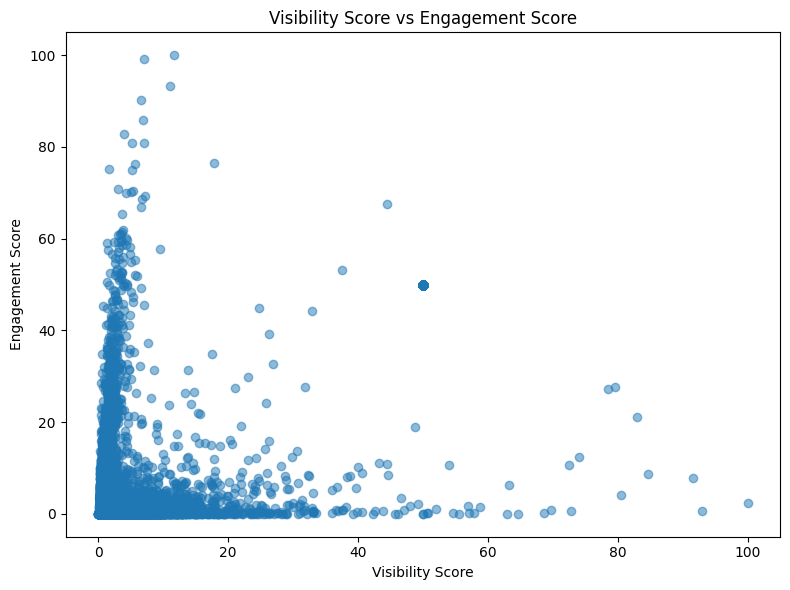

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(df["visibility_score"], df["engagement_score"], alpha=0.5)
plt.title("Visibility Score vs Engagement Score")
plt.xlabel("Visibility Score")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()

Engagement vs audience reception scatter plot

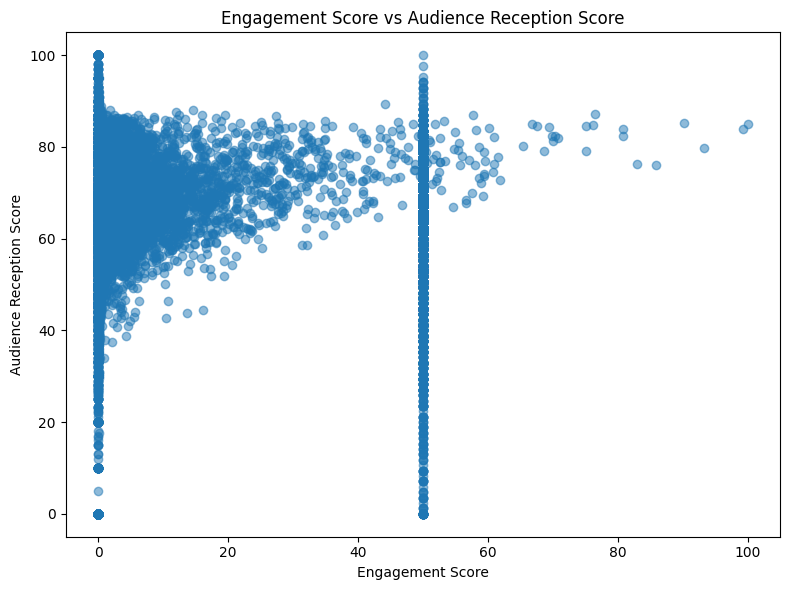

In [100]:
plt.figure(figsize=(8, 6))
plt.scatter(df["engagement_score"], df["audience_reception_score"], alpha=0.5)
plt.title("Engagement Score vs Audience Reception Score")
plt.xlabel("Engagement Score")
plt.ylabel("Audience Reception Score")
plt.tight_layout()
plt.show()

Visibility vs business value scatter plot

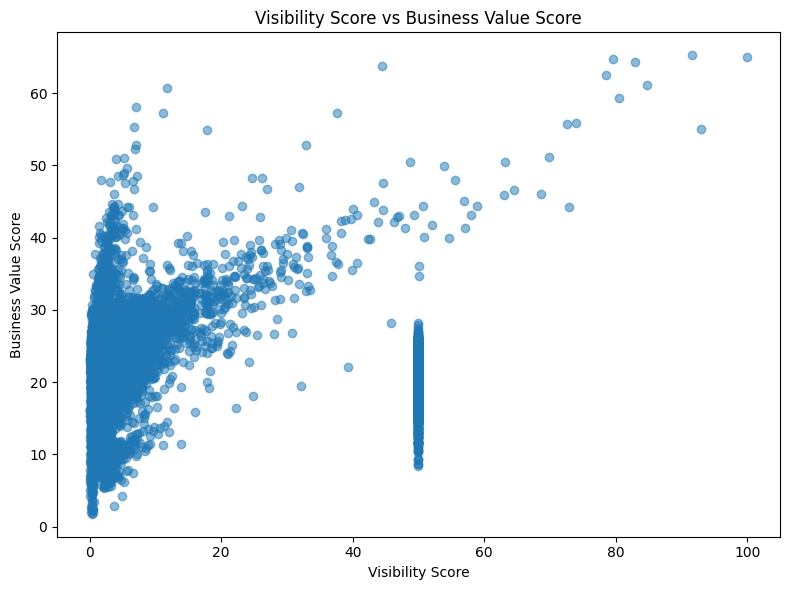

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(df["visibility_score"], df["business_value_score"], alpha=0.5)
plt.title("Visibility Score vs Business Value Score")
plt.xlabel("Visibility Score")
plt.ylabel("Business Value Score")
plt.tight_layout()
plt.show()

Top 10 titles by business value

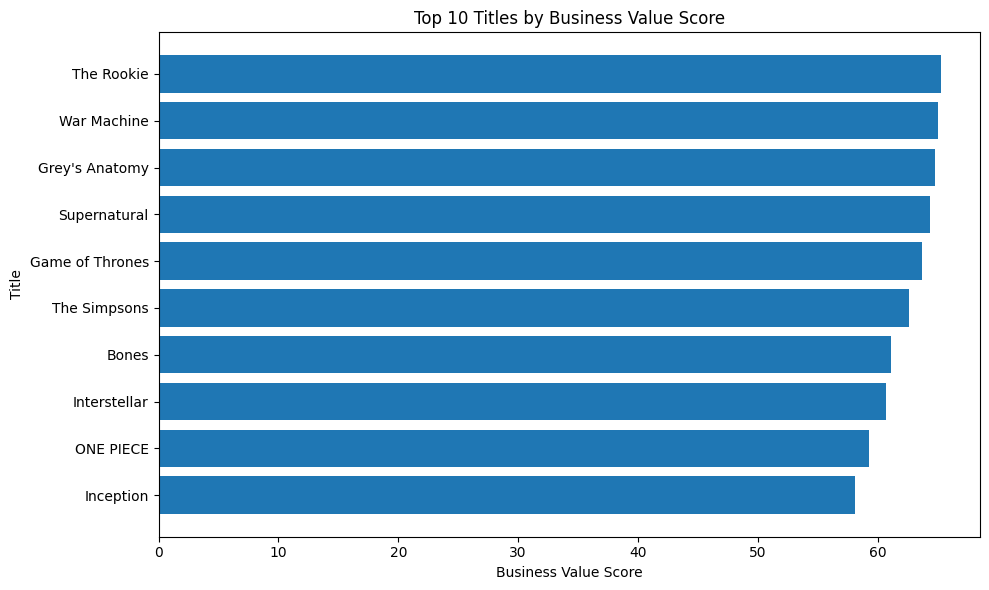

In [102]:
top_titles = df[["title", "business_value_score"]].dropna().sort_values(
    by="business_value_score", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_titles["title"][::-1], top_titles["business_value_score"][::-1])
plt.title("Top 10 Titles by Business Value Score")
plt.xlabel("Business Value Score")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

Annual average visibility evolution

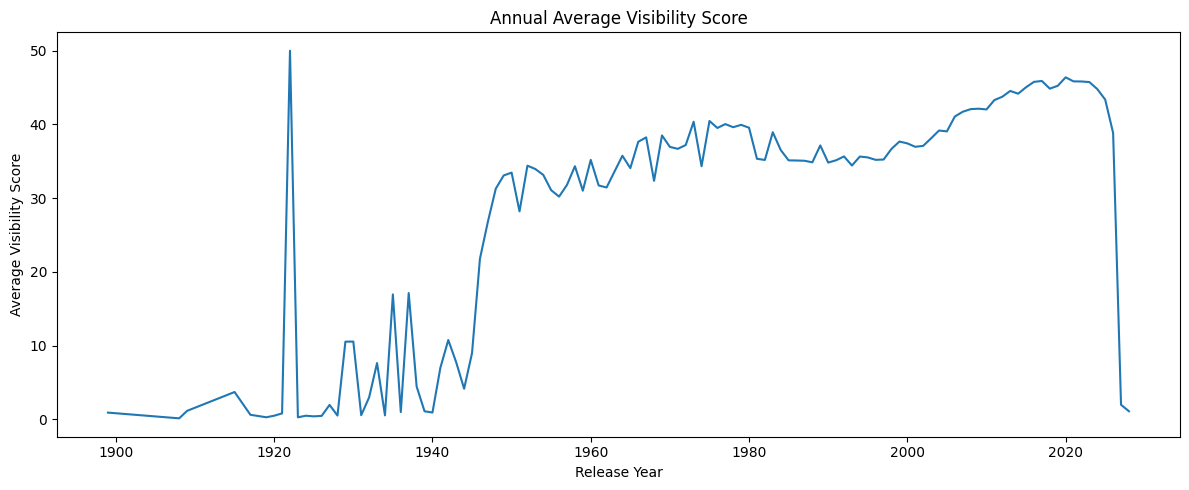

In [103]:
annual_visibility = df.groupby("release_year")["visibility_score"].mean().dropna()

plt.figure(figsize=(12, 5))
plt.plot(annual_visibility.index, annual_visibility.values)
plt.title("Annual Average Visibility Score")
plt.xlabel("Release Year")
plt.ylabel("Average Visibility Score")
plt.tight_layout()
plt.show()

Annual average engagement evolution

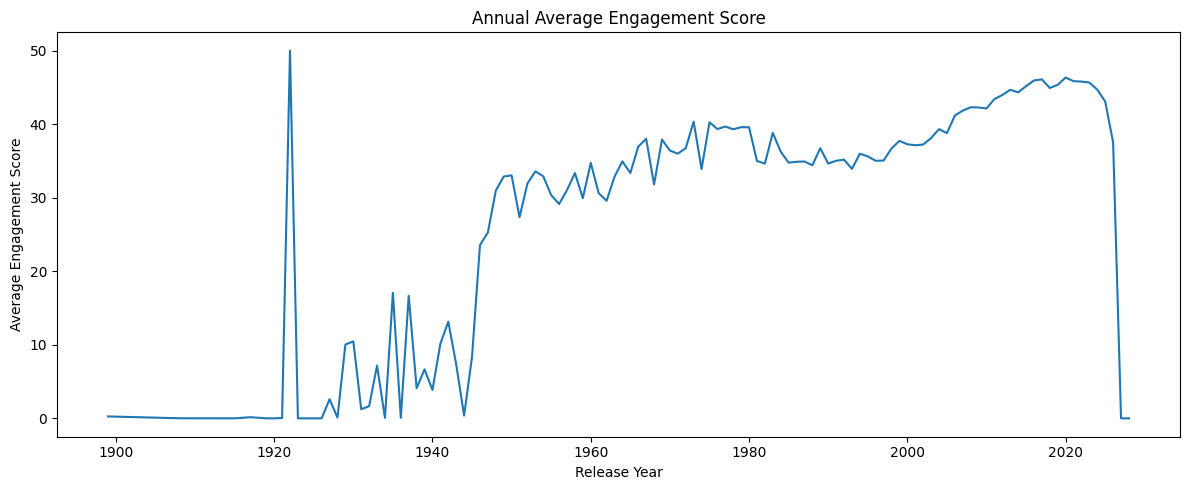

In [104]:
annual_engagement = df.groupby("release_year")["engagement_score"].mean().dropna()

plt.figure(figsize=(12, 5))
plt.plot(annual_engagement.index, annual_engagement.values)
plt.title("Annual Average Engagement Score")
plt.xlabel("Release Year")
plt.ylabel("Average Engagement Score")
plt.tight_layout()
plt.show()

Annual average business value evolution

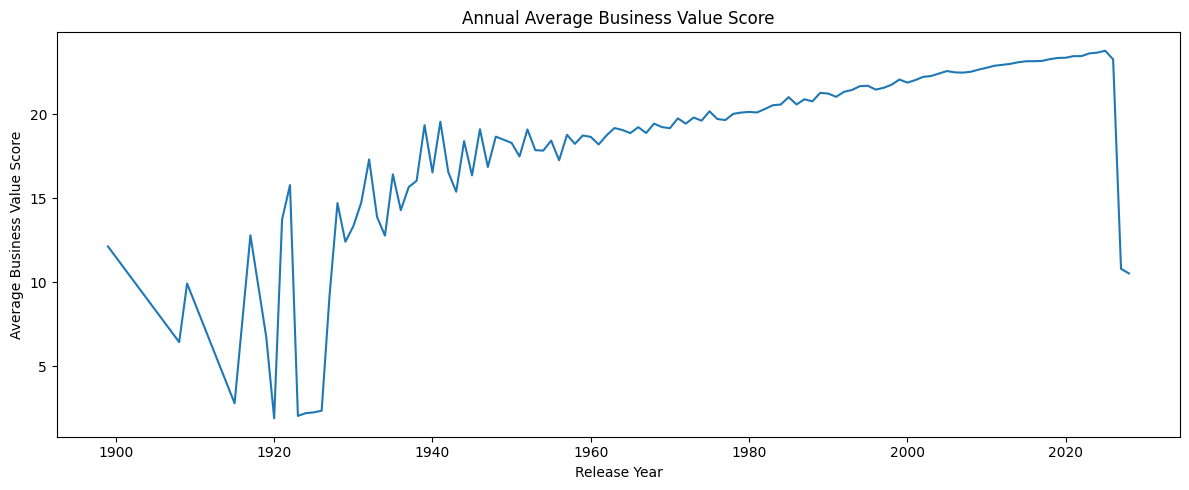

In [105]:
annual_business = df.groupby("release_year")["business_value_score"].mean().dropna()

plt.figure(figsize=(12, 5))
plt.plot(annual_business.index, annual_business.values)
plt.title("Annual Average Business Value Score")
plt.xlabel("Release Year")
plt.ylabel("Average Business Value Score")
plt.tight_layout()
plt.show()

Movie vs TV over time

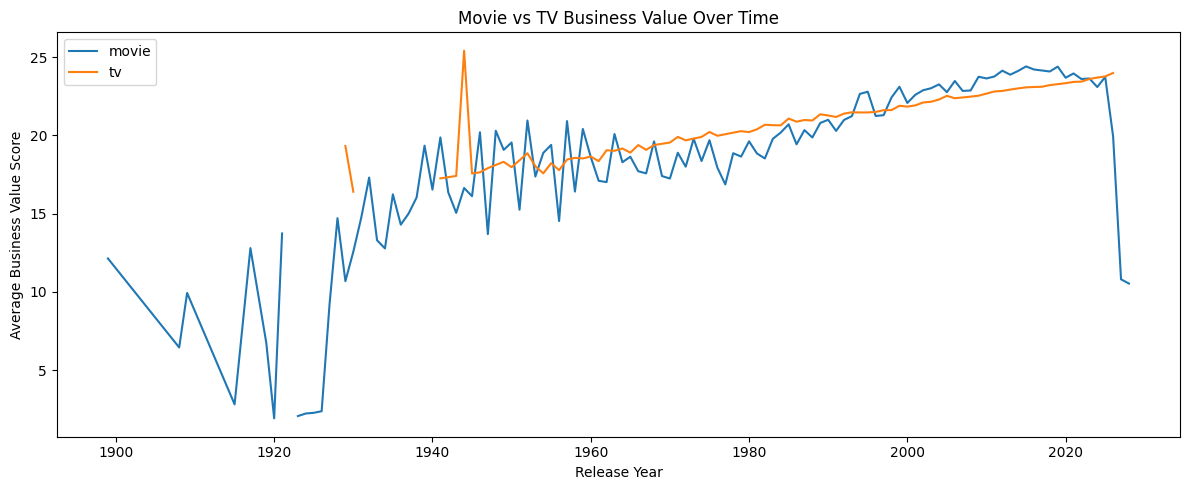

In [106]:
movie_tv_year = (
    df.groupby(["release_year", "content_type"])["business_value_score"]
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 5))
for col in movie_tv_year.columns:
    plt.plot(movie_tv_year.index, movie_tv_year[col], label=col)

plt.title("Movie vs TV Business Value Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Business Value Score")
plt.legend()
plt.tight_layout()
plt.show()

Marketing segment counts

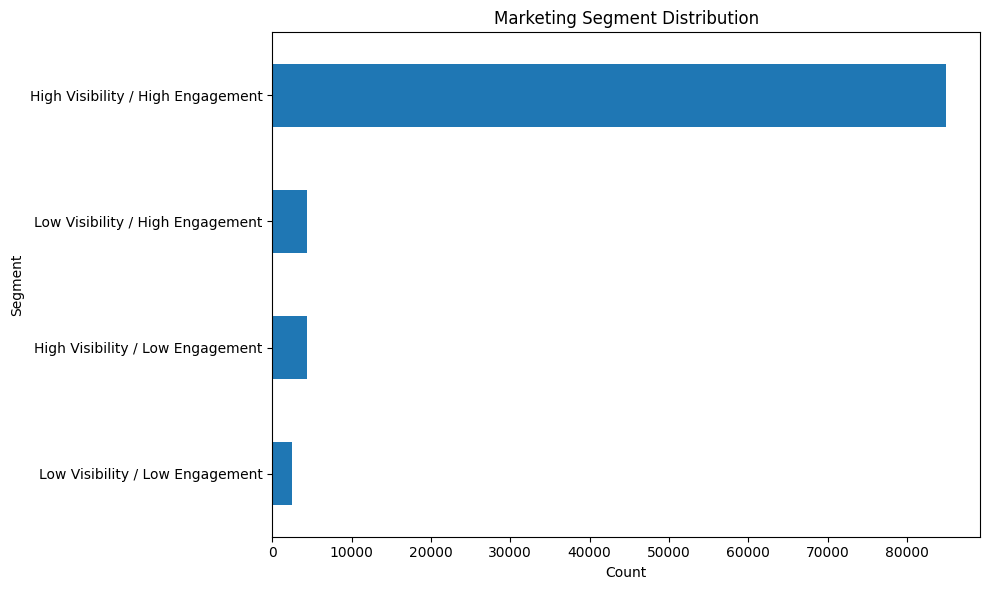

In [107]:
segment_counts = df["marketing_segment"].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.sort_values().plot(kind="barh")
plt.title("Marketing Segment Distribution")
plt.xlabel("Count")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

Hidden gems count

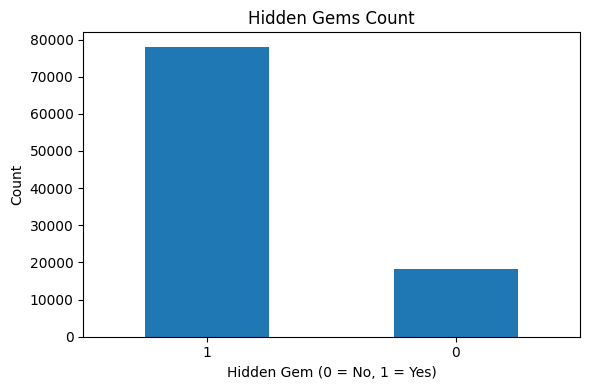

In [108]:
hidden_gem_counts = df["hidden_gem"].value_counts()

plt.figure(figsize=(6, 4))
hidden_gem_counts.plot(kind="bar")
plt.title("Hidden Gems Count")
plt.xlabel("Hidden Gem (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Tentpole content count

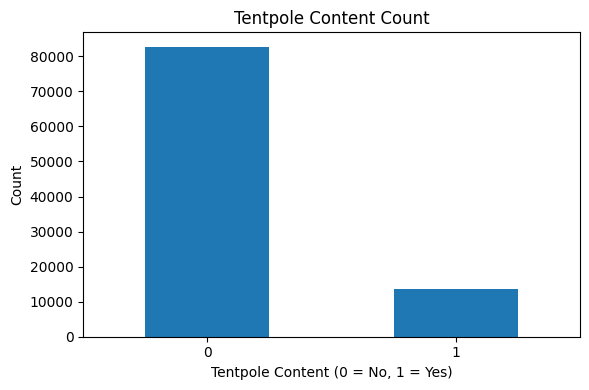

In [109]:
tentpole_counts = df["tentpole_content"].value_counts()

plt.figure(figsize=(6, 4))
tentpole_counts.plot(kind="bar")
plt.title("Tentpole Content Count")
plt.xlabel("Tentpole Content (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average business value by source

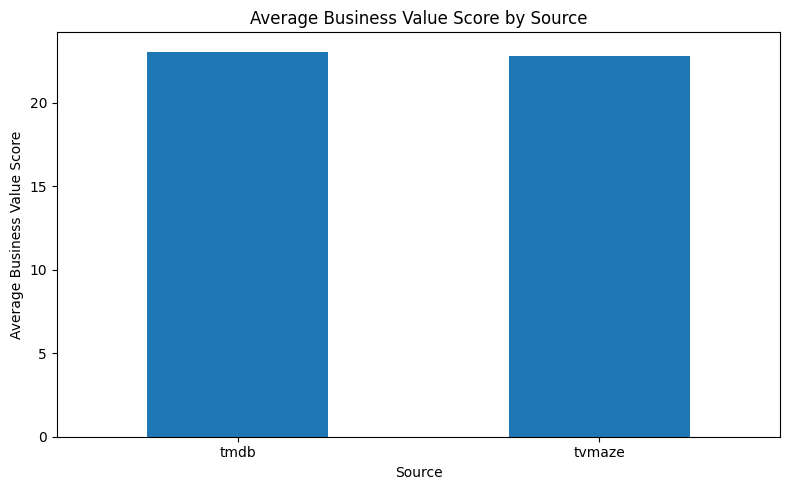

In [110]:
source_business = df.groupby("source")["business_value_score"].mean()

plt.figure(figsize=(8, 5))
source_business.plot(kind="bar")
plt.title("Average Business Value Score by Source")
plt.xlabel("Source")
plt.ylabel("Average Business Value Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 origin countries by content volume

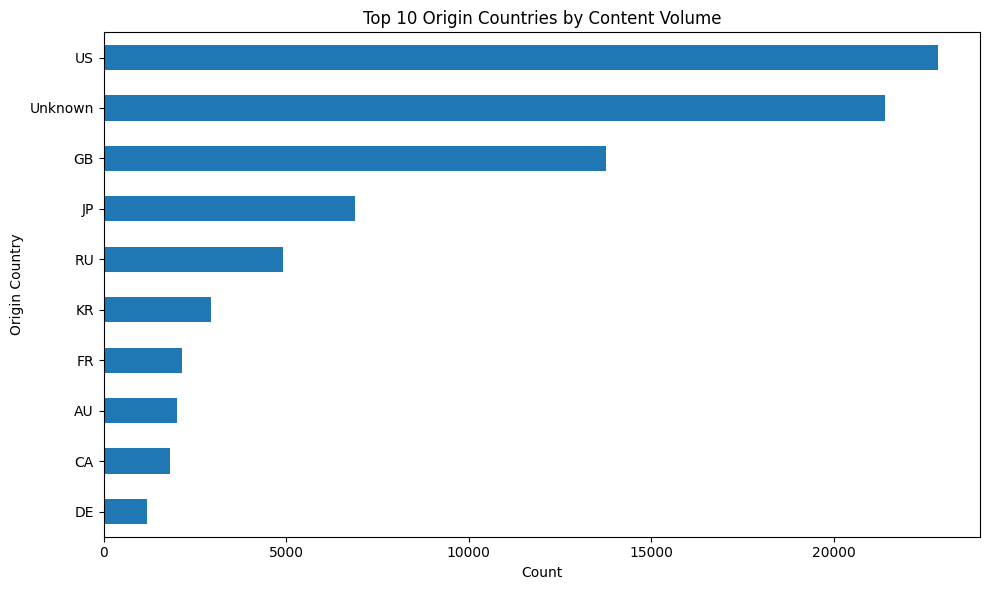

In [111]:
top_countries = df["origin_country"].fillna("Unknown").value_counts().head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Origin Countries by Content Volume")
plt.xlabel("Count")
plt.ylabel("Origin Country")
plt.tight_layout()
plt.show()

Runtime distribution

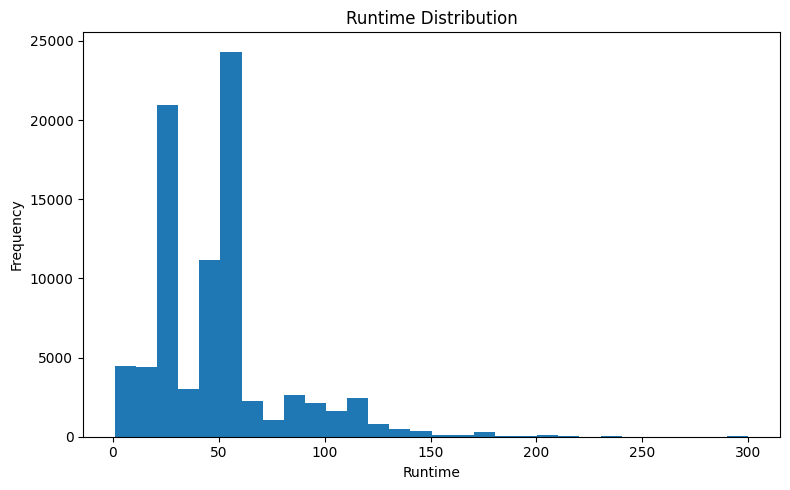

In [122]:
plt.figure(figsize=(8, 5))
plt.hist(df["runtime_final"].dropna(), bins=30)
plt.title("Runtime Distribution")
plt.xlabel("Runtime")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Correlation heatmap-like version using pandas

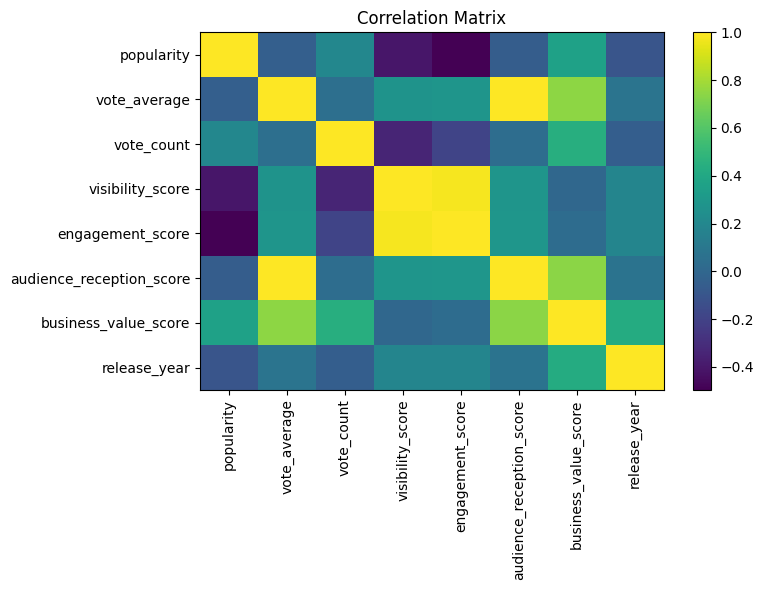

In [ ]:
numeric_cols = [
    "popularity",
    "vote_average",
    "vote_count",
    "visibility_score",
    "engagement_score",
    "audience_reception_score",
    "business_value_score",
    "release_year"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

High visibility but low engagement titles

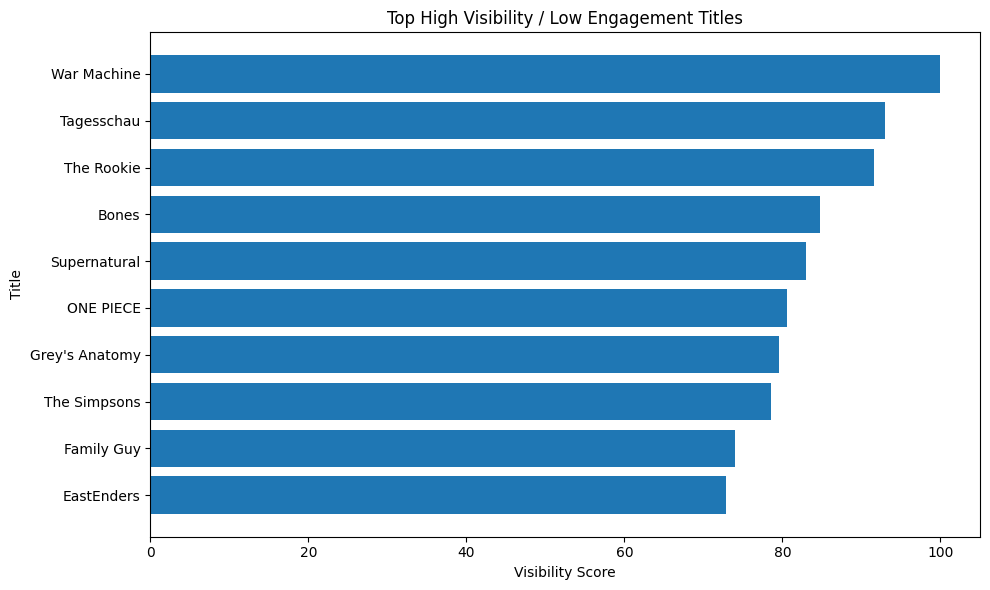

In [ ]:
visibility_threshold = df["visibility_score"].median()
engagement_threshold = df["engagement_score"].median()

high_vis_low_eng = df[
    (df["visibility_score"] >= visibility_threshold) &
    (df["engagement_score"] < engagement_threshold)
]

top_problem_titles = high_vis_low_eng[["title", "visibility_score", "engagement_score"]].sort_values(
    by="visibility_score", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_problem_titles["title"][::-1], top_problem_titles["visibility_score"][::-1])
plt.title("Top High Visibility / Low Engagement Titles")
plt.xlabel("Visibility Score")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

Low visibility but high engagement titles

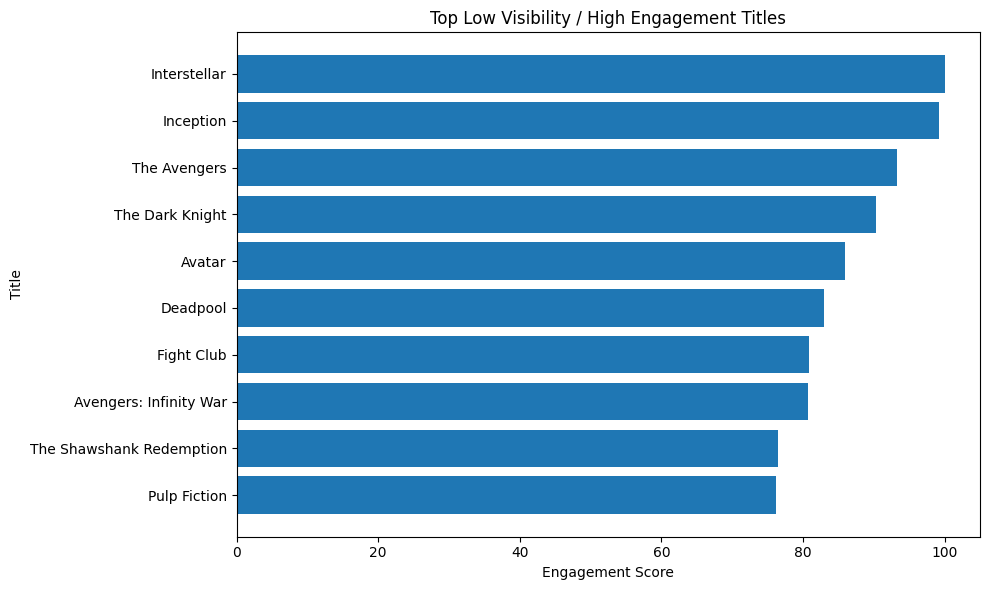

In [ ]:
low_vis_high_eng = df[
    (df["visibility_score"] < visibility_threshold) &
    (df["engagement_score"] >= engagement_threshold)
]

top_opportunity_titles = low_vis_high_eng[["title", "visibility_score", "engagement_score"]].sort_values(
    by="engagement_score", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_opportunity_titles["title"][::-1], top_opportunity_titles["engagement_score"][::-1])
plt.title("Top Low Visibility / High Engagement Titles")
plt.xlabel("Engagement Score")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

Business value by release year box-style alternative

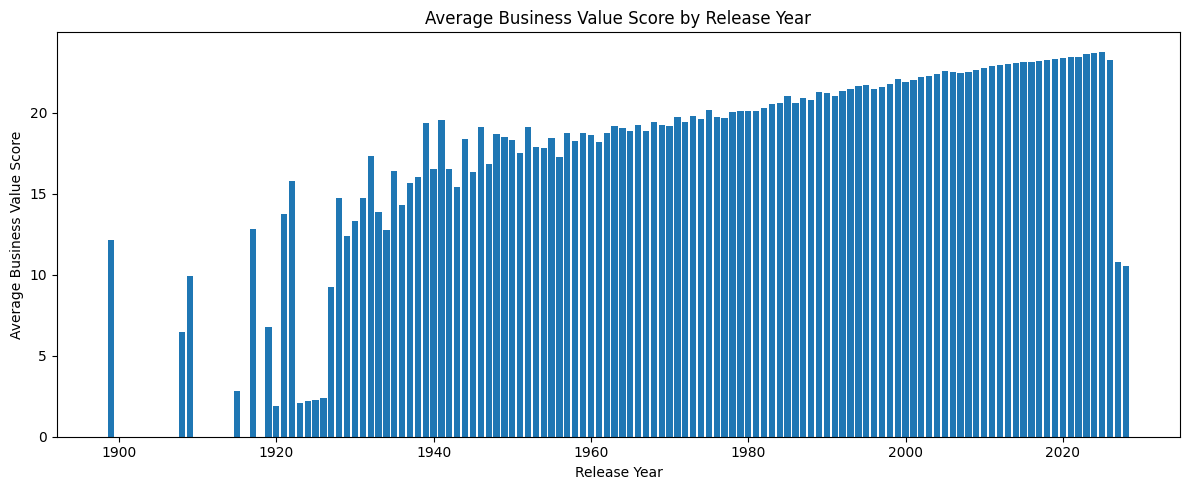

In [113]:
year_business = df.groupby("release_year")["business_value_score"].mean().dropna()

plt.figure(figsize=(12, 5))
plt.bar(year_business.index, year_business.values)
plt.title("Average Business Value Score by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Business Value Score")
plt.tight_layout()
plt.show()

Average audience reception by genre

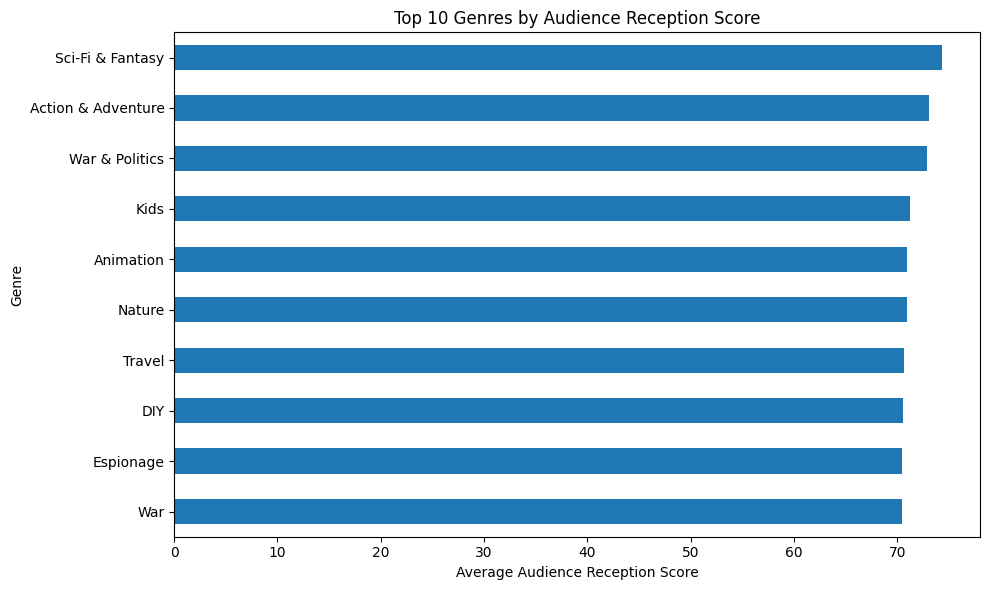

In [114]:
genre_exploded = df.copy()
genre_exploded["genre_names"] = genre_exploded["genre_names"].fillna("Unknown")
genre_exploded["genre_names"] = genre_exploded["genre_names"].str.split(", ")
genre_exploded = genre_exploded.explode("genre_names")

genre_reception = (
    genre_exploded.groupby("genre_names")["audience_reception_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
genre_reception.sort_values().plot(kind="barh")
plt.title("Top 10 Genres by Audience Reception Score")
plt.xlabel("Average Audience Reception Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Count of titles by source and content type

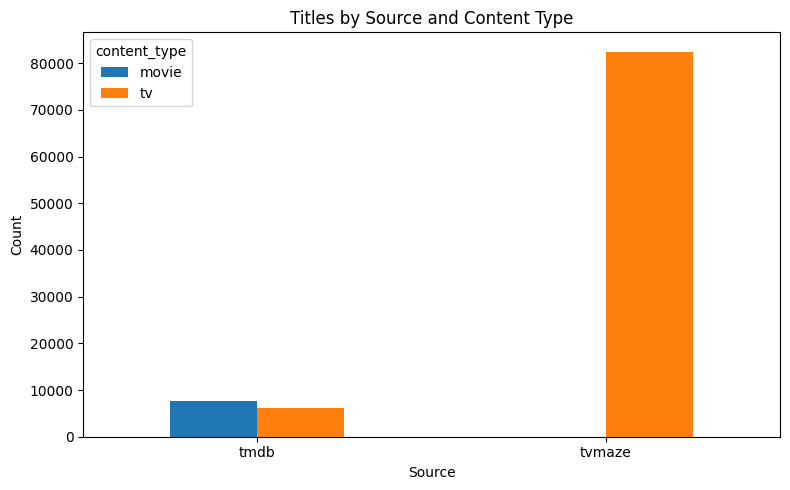

In [115]:
source_type = df.groupby(["source", "content_type"]).size().unstack(fill_value=0)

source_type.plot(kind="bar", figsize=(8, 5))
plt.title("Titles by Source and Content Type")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Recent vs older titles comparison

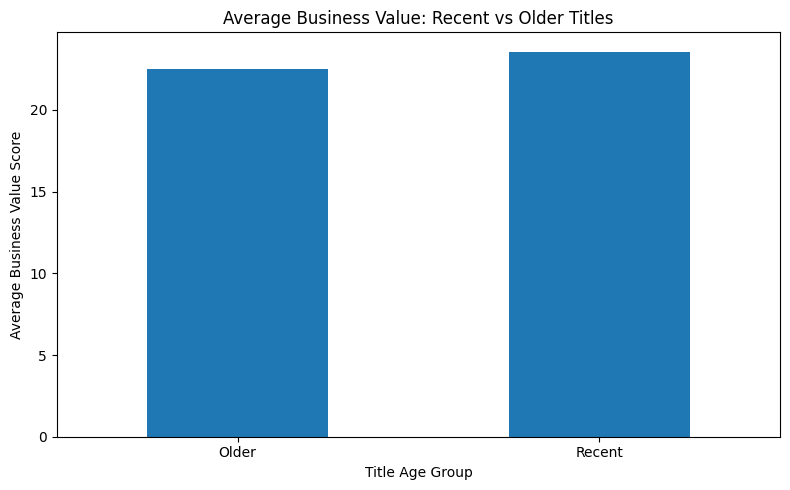

In [116]:
df["is_recent_label"] = np.where(df["is_recent"] == 1, "Recent", "Older")

recent_business = df.groupby("is_recent_label")["business_value_score"].mean()

plt.figure(figsize=(8, 5))
recent_business.plot(kind="bar")
plt.title("Average Business Value: Recent vs Older Titles")
plt.xlabel("Title Age Group")
plt.ylabel("Average Business Value Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 hidden gems by audience reception

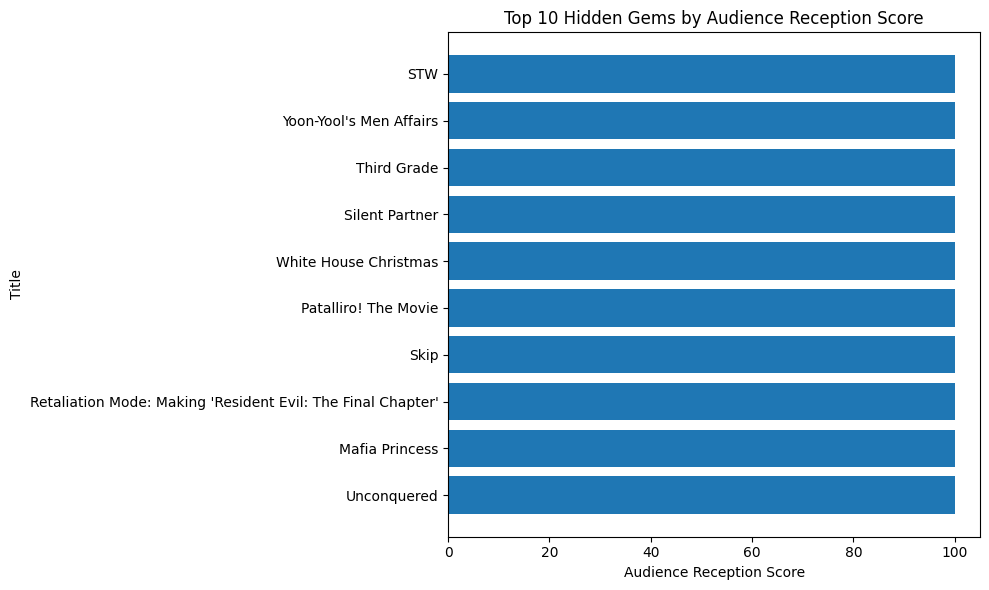

In [117]:
hidden_gems = df[df["hidden_gem"] == 1].sort_values(
    by="audience_reception_score", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(hidden_gems["title"][::-1], hidden_gems["audience_reception_score"][::-1])
plt.title("Top 10 Hidden Gems by Audience Reception Score")
plt.xlabel("Audience Reception Score")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

Top 10 tentpole titles

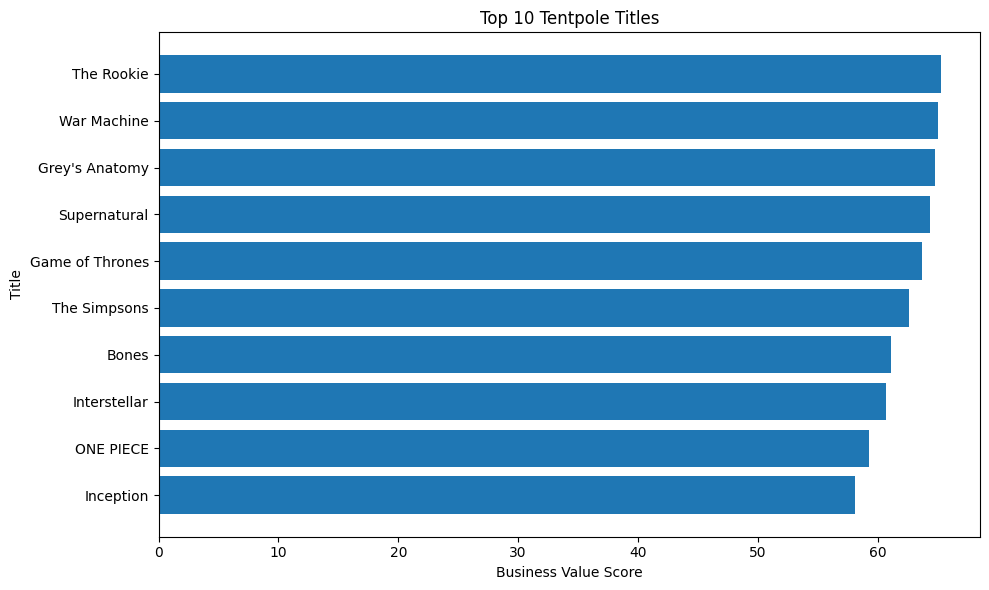

In [118]:
tentpoles = df[df["tentpole_content"] == 1].sort_values(
    by="business_value_score", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(tentpoles["title"][::-1], tentpoles["business_value_score"][::-1])
plt.title("Top 10 Tentpole Titles")
plt.xlabel("Business Value Score")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

Business value distribution

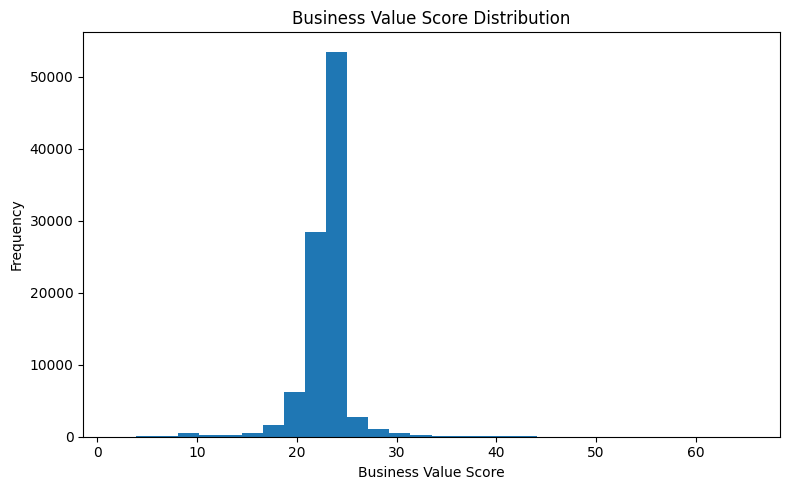

In [119]:
plt.figure(figsize=(8, 5))
plt.hist(df["business_value_score"].dropna(), bins=30)
plt.title("Business Value Score Distribution")
plt.xlabel("Business Value Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Audience reception distribution

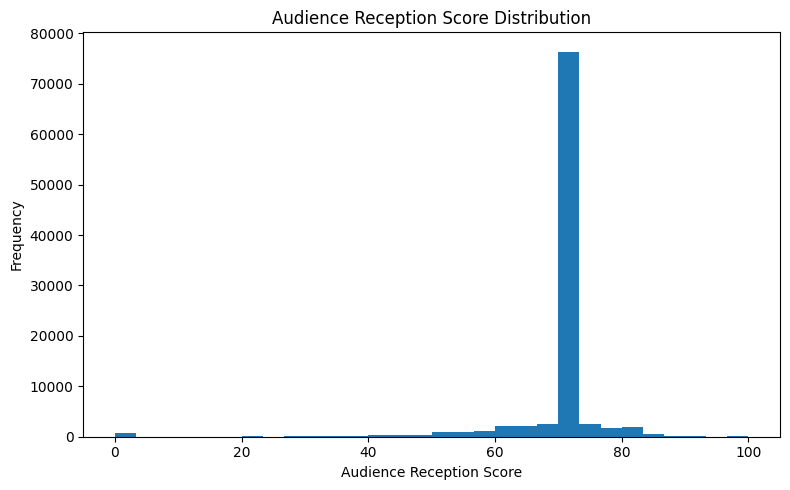

In [120]:
plt.figure(figsize=(8, 5))
plt.hist(df["audience_reception_score"].dropna(), bins=30)
plt.title("Audience Reception Score Distribution")
plt.xlabel("Audience Reception Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()